In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform

                Hours of Sleep  Stress Level  Screen Time  Mood Score
Hours of Sleep        1.000000     -0.965721    -0.974757    0.996946
Stress Level         -0.965721      1.000000     0.993374   -0.974040
Screen Time          -0.974757      0.993374     1.000000   -0.982660
Mood Score            0.996946     -0.974040    -0.982660    1.000000


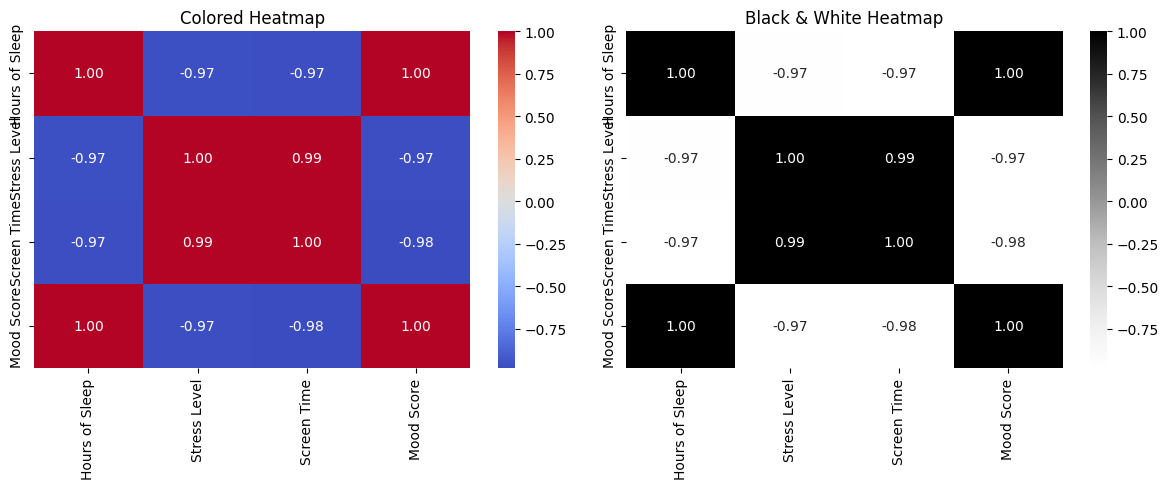

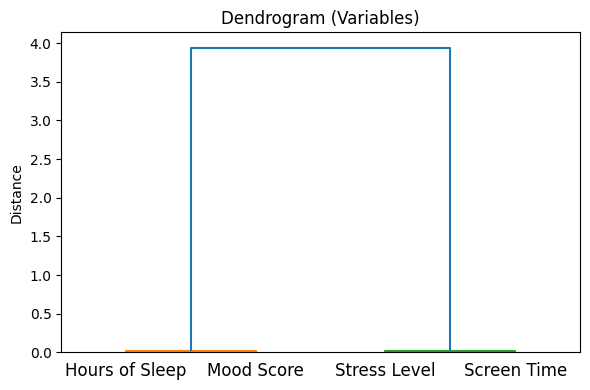

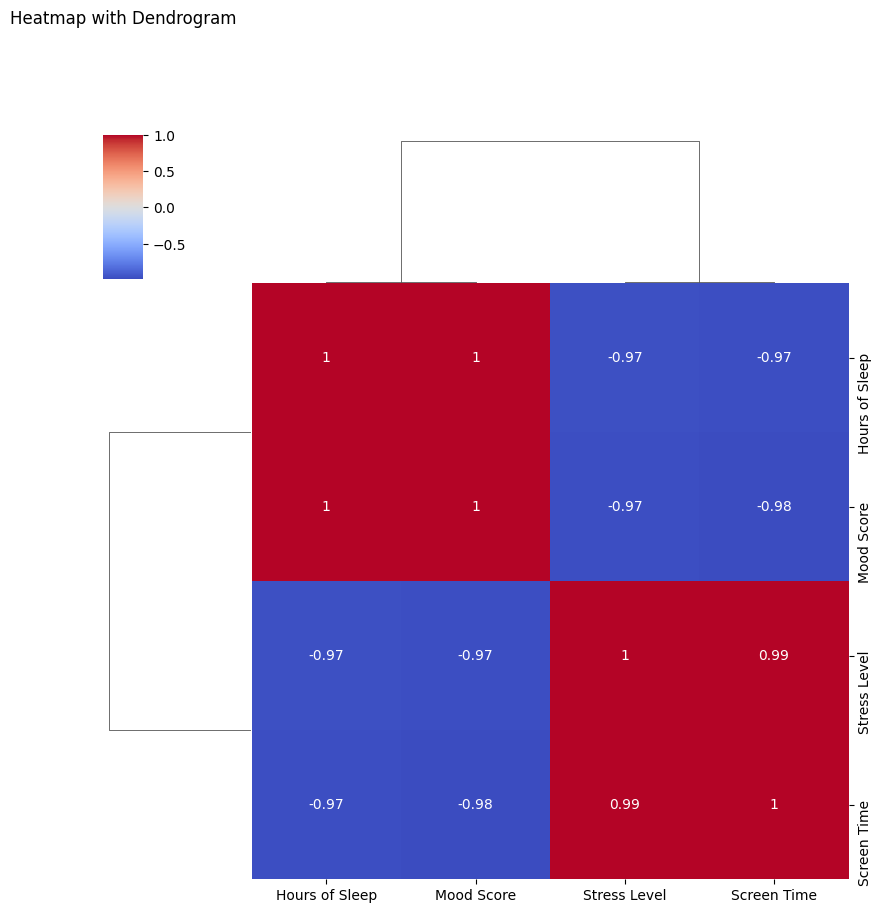

In [2]:
# Step 1: Create the dataset (Changed)
data = {
    'Hours of Sleep': [5.5, 6.8, 7.2, 8.1, 6.0],
    'Stress Level': [7.0, 5.5, 3.2, 2.0, 6.3],
    'Screen Time': [5.2, 4.0, 2.5, 1.0, 4.8],
    'Mood Score': [4.2, 5.8, 6.5, 7.8, 5.0]
}
df = pd.DataFrame(data)

# Step 2: Correlation matrix
corr_matrix = df.corr()

print(corr_matrix)

# Step 3: Plot simple heatmaps (color and B/W)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Colored heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Colored Heatmap")

# Black & White heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Greys', fmt=".2f", ax=axes[1])
axes[1].set_title("Black & White Heatmap")

plt.tight_layout()
plt.show()

# Step 4: Dendrogram (separate from heatmap)
plt.figure(figsize=(6, 4))
linkage = sch.linkage(pdist(corr_matrix), method='average')
sch.dendrogram(linkage, labels=corr_matrix.columns)
plt.title("Dendrogram (Variables)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Step 5: Heatmap with dendrogram (Clustermap)
sns.clustermap(corr_matrix, annot=True, cmap='coolwarm', figsize=(8, 8))
plt.title("Heatmap with Dendrogram", pad=80)
plt.show()


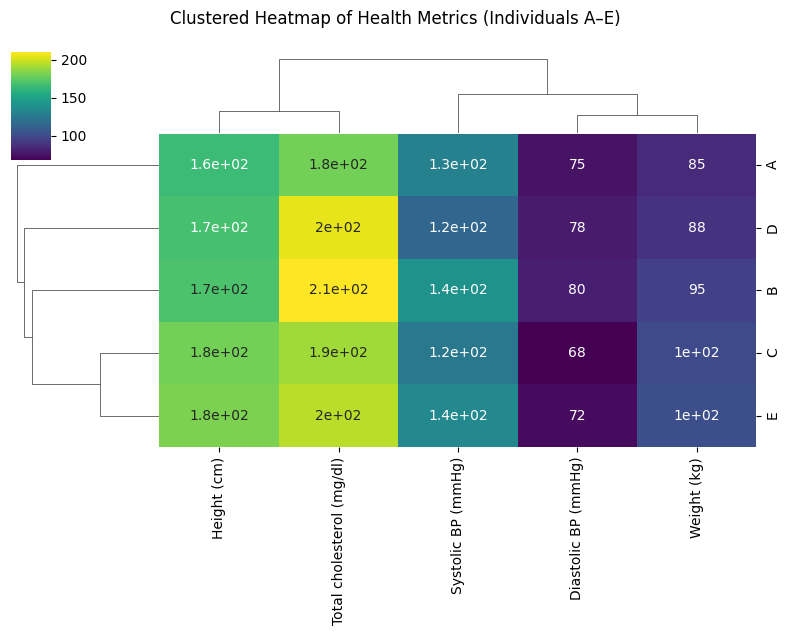

In [3]:
# Step 1: Create the new DataFrame
data = {
    'A': [75, 130, 85, 165, 180],
    'B': [80, 140, 95, 170, 210],
    'C': [68, 125, 100, 180, 190],
    'D': [78, 115, 88, 168, 205],
    'E': [72, 135, 102, 182, 195]
}

metrics = [
    'Diastolic BP (mmHg)',
    'Systolic BP (mmHg)',
    'Weight (kg)',
    'Height (cm)',
    'Total cholesterol (mg/dl)'
]

df = pd.DataFrame(data, index=metrics)

# Step 2: Transpose so individuals are rows
df_t = df.T

# Step 3: Generate clustered heatmap
sns.clustermap(df_t, cmap='viridis', annot=True, figsize=(8, 6))
plt.suptitle("Clustered Heatmap of Health Metrics (Individuals A–E)", y=1.05)
plt.show()

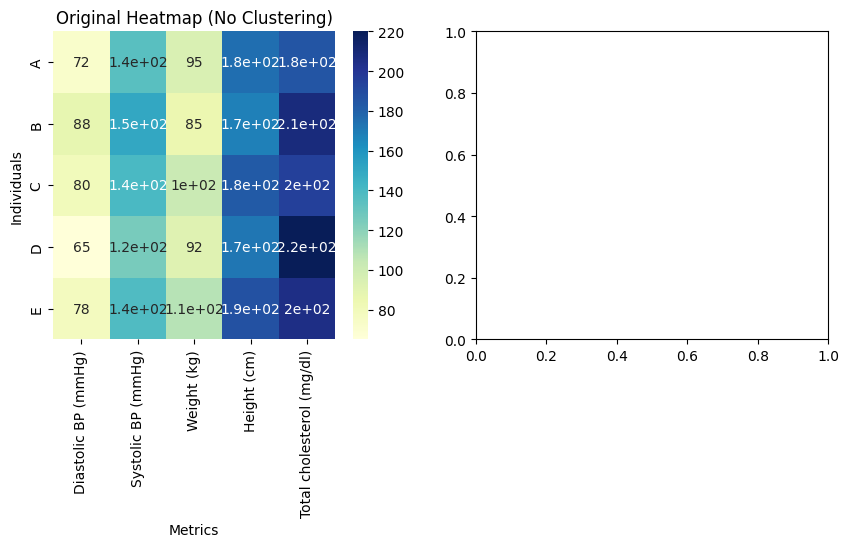

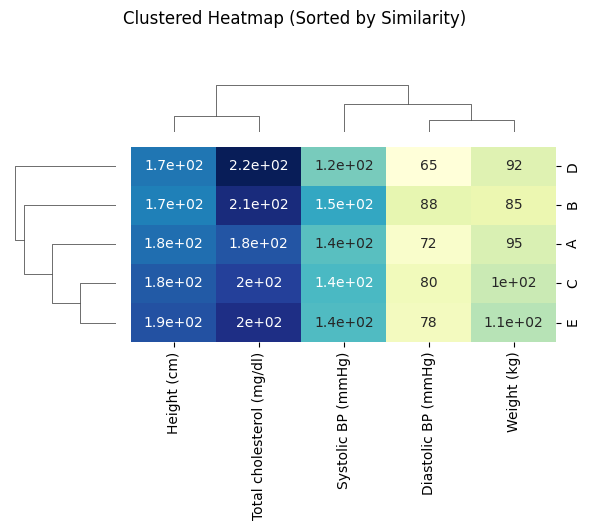

In [5]:
# Step 1: Create the DataFrame
data = {
    'A': [72, 135, 95, 175, 185],
    'B': [88, 150, 85, 168, 208],
    'C': [80, 140, 102, 183, 195],
    'D': [65, 125, 92, 172, 220],
    'E': [78, 138, 108, 187, 205]
}

metrics = [
    'Diastolic BP (mmHg)',
    'Systolic BP (mmHg)',
    'Weight (kg)',
    'Height (cm)',
    'Total cholesterol (mg/dl)'
]

df = pd.DataFrame(data, index=metrics)
df_t = df.T  # Transpose: rows = individuals, columns = metrics

# --- Plot 1: Heatmap BEFORE clustering ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(df_t, annot=True, cmap="YlGnBu")
plt.title("Original Heatmap (No Clustering)")
plt.xlabel("Metrics")
plt.ylabel("Individuals")

# --- Plot 2: Heatmap AFTER clustering ---
plt.subplot(1, 2, 2)
sns.clustermap(df_t, cmap="YlGnBu", annot=True, figsize=(6, 5), cbar_pos=None)
plt.suptitle("Clustered Heatmap (Sorted by Similarity)", y=1.05)

plt.tight_layout()
plt.show()

🔢 Pairwise Distance Matrix:

   A  B  C  D
A  0  5  8  3
B  5  0  4  7
C  8  4  0  6
D  3  7  6  0


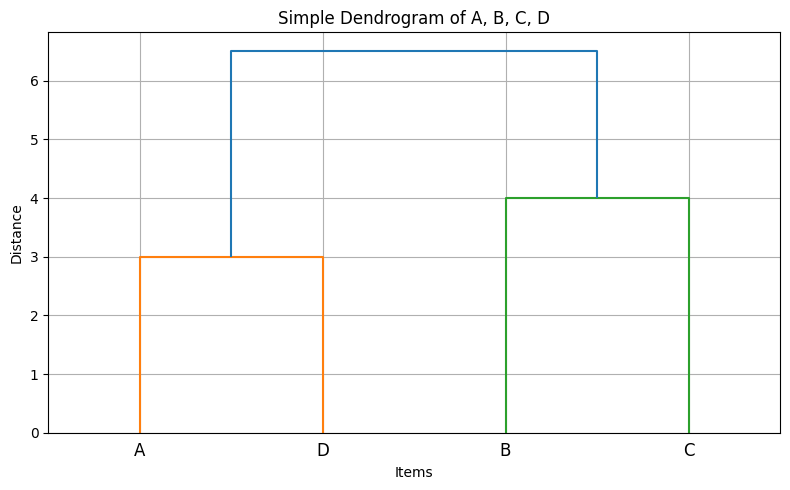

In [6]:
# Define labels
labels = ['A', 'B', 'C', 'D']

# Define pairwise distance matrix (symmetric)
distance_matrix = np.array([
    [0, 5, 8, 3],
    [5, 0, 4, 7],
    [8, 4, 0, 6],
    [3, 7, 6, 0]
])

# Create a DataFrame to display distances clearly
df_dist = pd.DataFrame(distance_matrix, index=labels, columns=labels)
print("🔢 Pairwise Distance Matrix:\n")
print(df_dist)

# Convert to condensed format for clustering
condensed_dist = squareform(distance_matrix)

# Hierarchical clustering using average linkage
linked = sch.linkage(condensed_dist, method='average')

# Plot dendrogram
plt.figure(figsize=(8, 5))
sch.dendrogram(linked, labels=labels)
plt.title("Simple Dendrogram of A, B, C, D")
plt.xlabel("Items")
plt.ylabel("Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

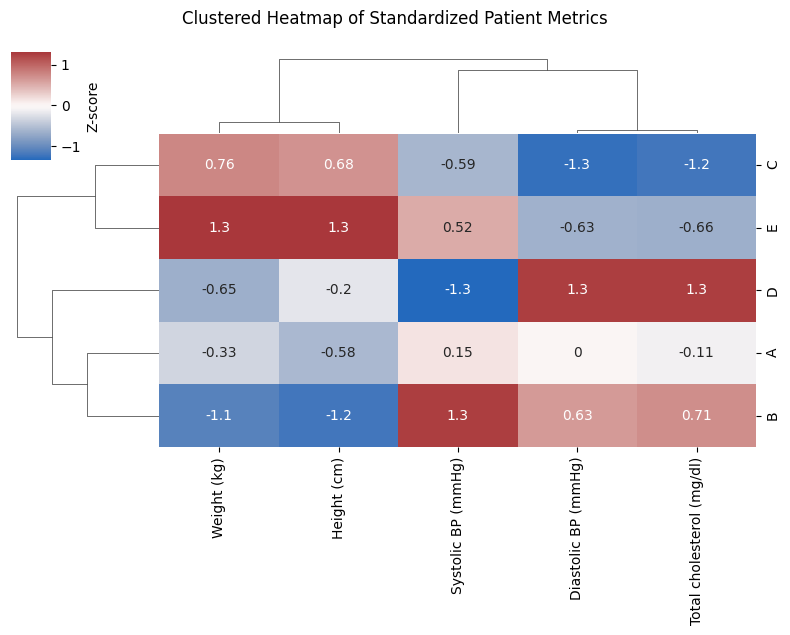

In [7]:
# Step 1: Original patient data
data = {
    'A': [75, 140, 95, 175, 205],
    'B': [80, 155, 88, 170, 220],
    'C': [65, 130, 105, 185, 185],
    'D': [85, 120, 92, 178, 230],
    'E': [70, 145, 110, 190, 195]
}

metrics = [
    'Diastolic BP (mmHg)',
    'Systolic BP (mmHg)',
    'Weight (kg)',
    'Height (cm)',
    'Total cholesterol (mg/dl)'
]


df = pd.DataFrame(data, index=metrics)

# Step 2: Transpose (patients as rows, metrics as columns)
df_t = df.T

# Step 3: Standardize each metric
df_standardized = (df_t - df_t.mean()) / df_t.std()

# Step 4: Plot standardized clustered heatmap
sns.clustermap(df_standardized, cmap='vlag', annot=True, figsize=(8, 6), cbar_kws={'label': 'Z-score'})
plt.suptitle("Clustered Heatmap of Standardized Patient Metrics", y=1.05)
plt.show()

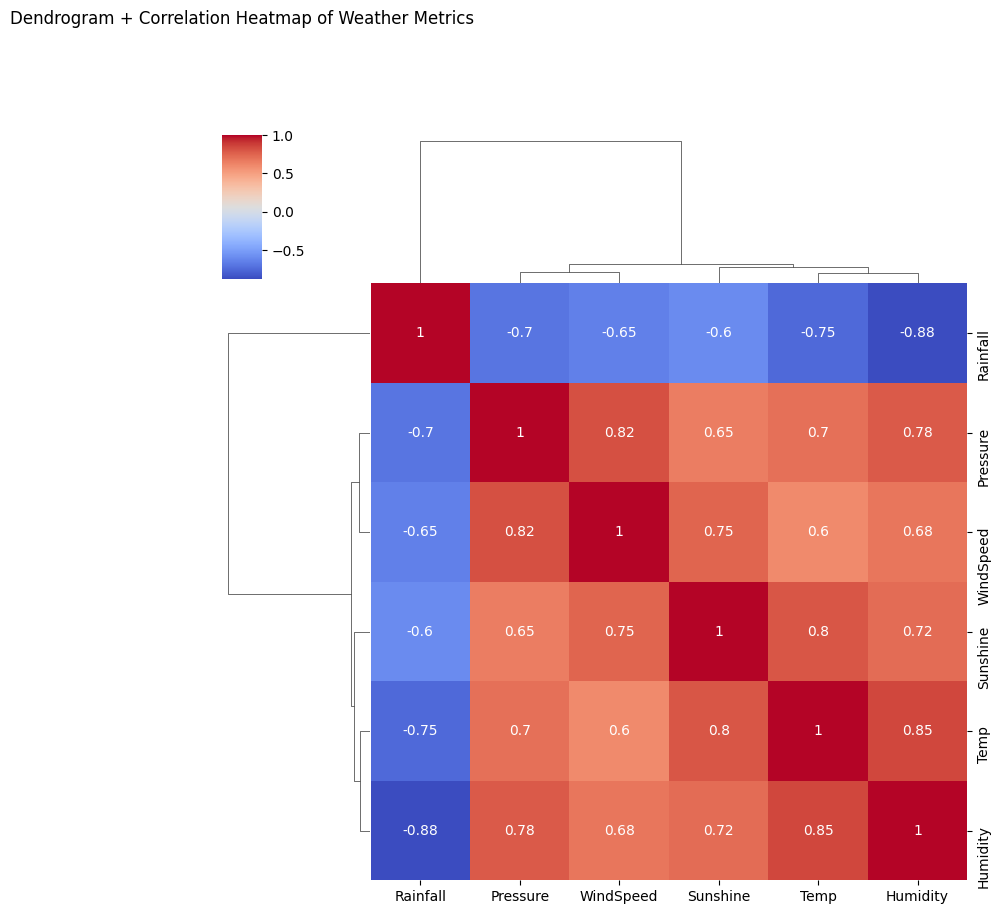

In [8]:
# Given correlation matrix
corr_data = {
    'Temp':     [1.000, 0.850, 0.700, 0.600, -0.750, 0.800],
    'Humidity': [0.850, 1.000, 0.780, 0.680, -0.880, 0.720],
    'Pressure': [0.700, 0.780, 1.000, 0.820, -0.700, 0.650],
    'WindSpeed':[0.600, 0.680, 0.820, 1.000, -0.650, 0.750],
    'Rainfall': [-0.750, -0.880, -0.700, -0.650, 1.000, -0.600],
    'Sunshine': [0.800, 0.720, 0.650, 0.750, -0.600, 1.000]
}

# Create DataFrame
df_corr = pd.DataFrame(corr_data, index=['Temp', 'Humidity', 'Pressure', 'WindSpeed', 'Rainfall', 'Sunshine'])

# Generate heatmap with dendrogram using clustermap
sns.clustermap(df_corr, annot=True, cmap='coolwarm', figsize=(8, 8))
plt.title("Dendrogram + Correlation Heatmap of Weather Metrics", pad=80)
plt.show()

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
from scipy.interpolate import make_interp_spline
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform
import folium
from folium.plugins import HeatMap

In [11]:
np.random.seed(24)

students = pd.DataFrame({
    'Hours_Studied': np.random.uniform(2, 12, 50),
    'Exam_Score': np.random.uniform(50, 95, 50)
})

students['Income'] = np.random.uniform(25_000, 150_000, 50)
students['Spending'] = np.random.uniform(10_000, 60_000, 50)
students['Purchases'] = np.random.randint(5, 40, 50)
students['Customer_Segment'] = np.random.choice(['D', 'E', 'F'], size=50)

students.head()

,Hours_Studied,Exam_Score,Income,Spending,Purchases,Customer_Segment
0,11.600173,91.249896,121145.326744,47449.268007,9,D
1,8.995120,50.091047,84323.031573,51962.682680,31,D
2,11.998673,93.709926,89889.146093,12278.731342,33,F
3,4.200673,90.007168,143024.130725,35282.153088,28,F
4,5.610564,81.476987,105440.670239,39440.740387,24,F


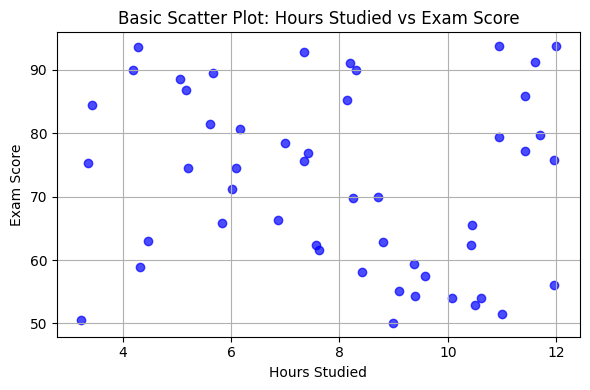

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(students['Hours_Studied'], students['Exam_Score'], color='blue', alpha=0.7)
plt.title("Basic Scatter Plot: Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.grid(True)
plt.tight_layout()
plt.show()

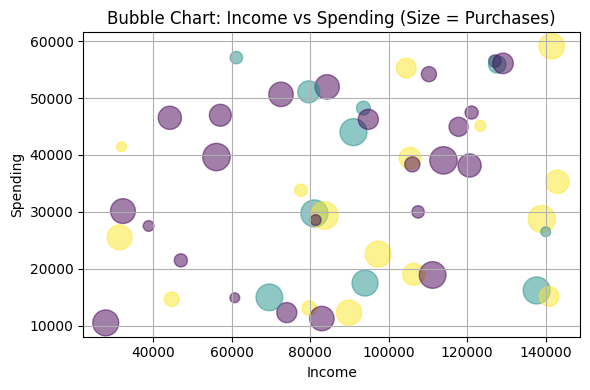

In [13]:
plt.figure(figsize=(6, 4))
sizes = students['Purchases'] * 10  # bubble size
colors = students['Customer_Segment'].astype('category').cat.codes  # color by segment
plt.scatter(students['Income'], students['Spending'], s=sizes, c=colors, alpha=0.5, cmap='viridis')
plt.title("Bubble Chart: Income vs Spending (Size = Purchases)")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.grid(True)
plt.tight_layout()
plt.show()

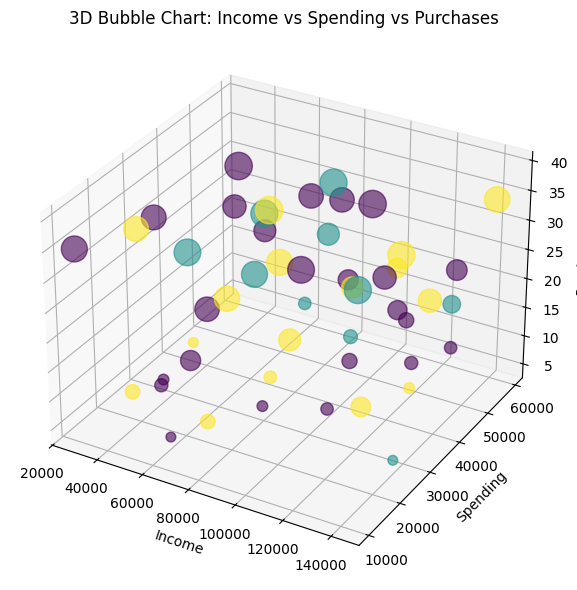

In [15]:
# Prepare data
x = students['Income']
y = students['Spending']
z = students['Purchases']
sizes = z * 10  # Bubble size
colors = students['Customer_Segment'].astype('category').cat.codes  # Color by category

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D scatter
scatter = ax.scatter(x, y, z, c=colors, s=sizes, cmap='viridis', alpha=0.6)

# Set axis labels
ax.set_title("3D Bubble Chart: Income vs Spending vs Purchases")
ax.set_xlabel("Income")
ax.set_ylabel("Spending")
ax.set_zlabel("Purchases")

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

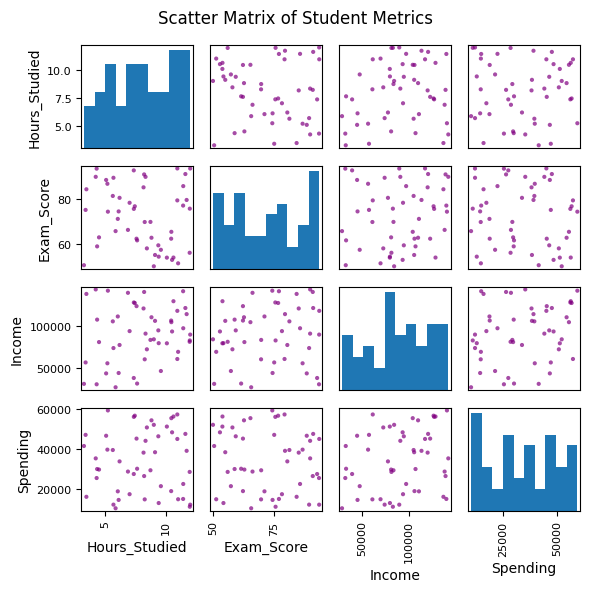

In [16]:
plt.figure(figsize=(8, 8))
scatter_matrix(students[['Hours_Studied', 'Exam_Score', 'Income', 'Spending']], alpha=0.7, figsize=(6, 6), diagonal='hist', color='purple')
plt.suptitle("Scatter Matrix of Student Metrics")
plt.tight_layout()
plt.show()

slope (m) =  -0.8069498537326943
y intercept (c) =  78.8792218115384
Y predictions based on x =  [69.51846388 71.62061064 69.19689445 75.48948935 74.35177838 71.29517632
 69.22442409 74.71256063 76.16347582 74.16679597 74.67889221 74.30853879
 71.53878986 70.00162408 72.95527835 75.26978543 71.84418003 72.73244989
 72.88713597 70.05564797 70.46451376 74.79595396 72.17209851 71.77613561
 69.43445832 70.05468328 69.66041799 72.08288452 72.30542392 75.42803242
 73.34328865 70.75146715 70.45288881 72.95071564 71.15027185 73.2331802
 70.40360239 72.26467988 70.31252775 75.39564191 74.0196212  72.22692845
 76.11108762 76.27439992 73.90171375 72.77155569 69.66854144 73.96280702
 71.32010736 69.23253434]
New Y if x is 8.5 =   72.0201480548105


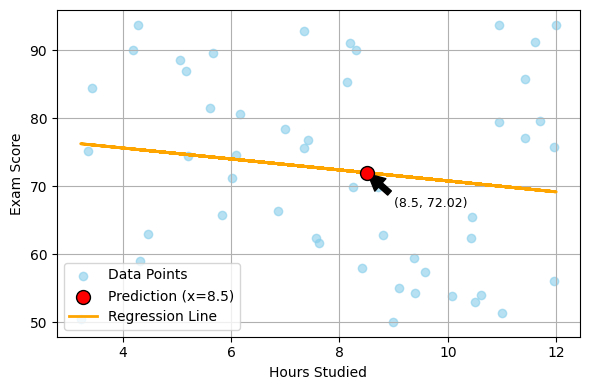

In [17]:
x = students["Hours_Studied"].values
y = students["Exam_Score"].values

x_bar = np.mean(x)
y_bar = np.mean(y)

# Formula
numerator = np.sum((x - x_bar)*(y - y_bar))
denominator = np.sum((x - x_bar) ** 2)
m = numerator / denominator


c = y_bar - m * x_bar

y_pred = m * x + c


new_x = 8.5
new_y = m * new_x + c


print("slope (m) = ", m)
print("y intercept (c) = ", c)
print("Y predictions based on x = ", y_pred)
print("New Y if x is 8.5 =  ", new_y)

# Draw the regression line based x, y_pred but the scatter plot based on x, y
plt.figure(figsize=(6, 4))

# Plot the original data points
plt.scatter(x, y, color='skyblue', label='Data Points', alpha=0.6)

# Plot the predicted point
plt.scatter(new_x, new_y, color='red', s=100, label=f'Prediction (x={new_x})', edgecolor='black', zorder=5)

# Annotate the predicted point
plt.annotate(f"({new_x}, {new_y:.2f})", xy=(new_x, new_y), xytext=(new_x + 0.5, new_y - 5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=9)

plt.plot(x, y_pred, color='orange', linewidth=2, label='Regression Line')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


slope (m) =  -0.8069498537326943
y intercept (c) =  78.8792218115384
Y predictions based on x =  [69.51846388 71.62061064 69.19689445 75.48948935 74.35177838 71.29517632
 69.22442409 74.71256063 76.16347582 74.16679597 74.67889221 74.30853879
 71.53878986 70.00162408 72.95527835 75.26978543 71.84418003 72.73244989
 72.88713597 70.05564797 70.46451376 74.79595396 72.17209851 71.77613561
 69.43445832 70.05468328 69.66041799 72.08288452 72.30542392 75.42803242
 73.34328865 70.75146715 70.45288881 72.95071564 71.15027185 73.2331802
 70.40360239 72.26467988 70.31252775 75.39564191 74.0196212  72.22692845
 76.11108762 76.27439992 73.90171375 72.77155569 69.66854144 73.96280702
 71.32010736 69.23253434]
New Y if x is 8.5 =   72.0201480548105


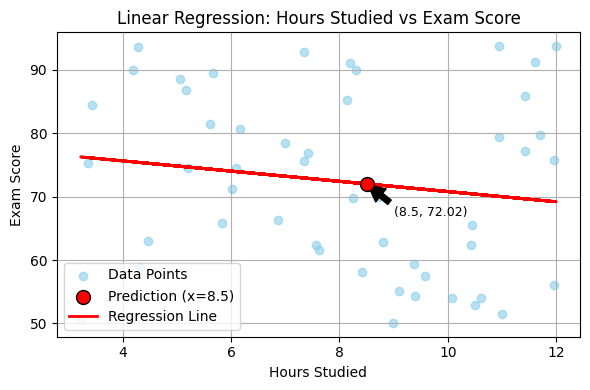

In [18]:
# Prepare data for LinearRegression
x = students[['Hours_Studied']]  # must be 2D for sklearn
y = students['Exam_Score']

# Create and train the model
model = LinearRegression()
model.fit(x, y)

# Predict using the model
y_pred = model.predict(x)

# Display slope (coefficient) and intercept
m = model.coef_[0] # slope
c = model.intercept_ # y intercept

new_x = 8.5
new_y = model.predict([[new_x]])[0]

print("slope (m) = ", m)
print("y intercept (c) = ", c)
print("Y predictions based on x = ", y_pred)
print("New Y if x is 8.5 =  ", new_y)

# Plotting
plt.figure(figsize=(6, 4))

# Plot the original data points
plt.scatter(x, y, color='skyblue', label='Data Points', alpha=0.6)

# Plot the predicted point
plt.scatter(new_x, new_y, color='red', s=100, label=f'Prediction (x={new_x})', edgecolor='black', zorder=5)

# Annotate the predicted point
plt.annotate(f"({new_x}, {new_y:.2f})", xy=(new_x, new_y), xytext=(new_x + 0.5, new_y - 5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=9)



plt.plot(x, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title("Linear Regression: Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
days = np.arange(1, 8)
sales_A = np.array([150, 160, 155, 170, 180, 190, 200])
sales_B = np.array([120, 130, 135, 140, 145, 150, 155])
sales_C = np.array([100, 105, 110, 115, 120, 125, 130])

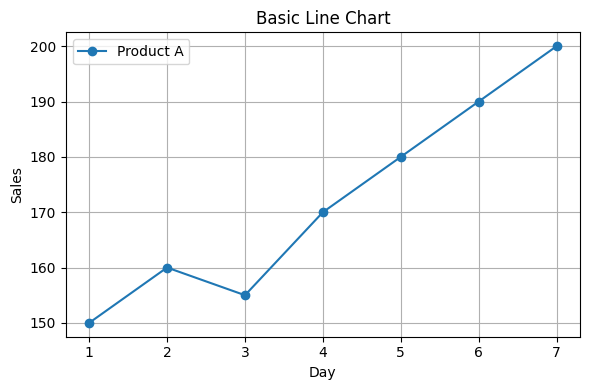

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(days, sales_A, marker='o', label='Product A')
plt.title("Basic Line Chart")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

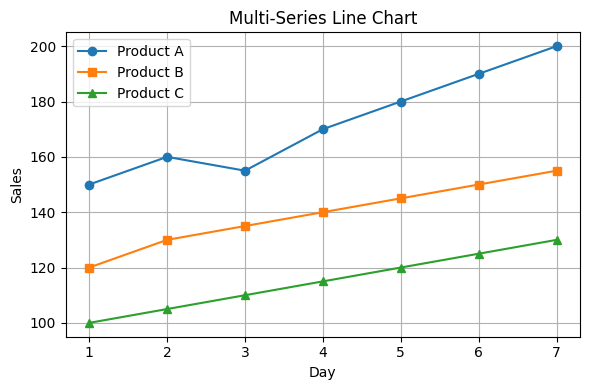

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(days, sales_A, marker='o', label='Product A')
plt.plot(days, sales_B, marker='s', label='Product B')
plt.plot(days, sales_C, marker='^', label='Product C')
plt.title("Multi-Series Line Chart")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

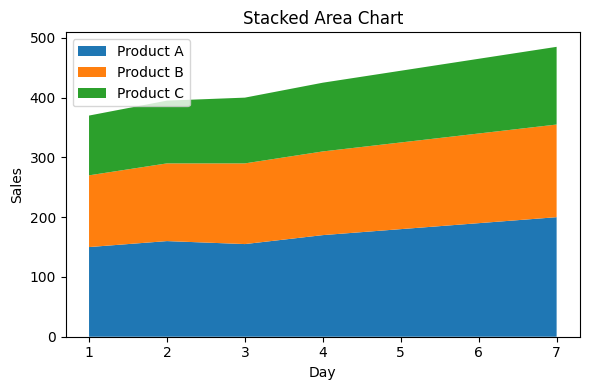

In [22]:
plt.figure(figsize=(6, 4))
plt.stackplot(days, sales_A, sales_B, sales_C, labels=['Product A', 'Product B', 'Product C'])
plt.title("Stacked Area Chart")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

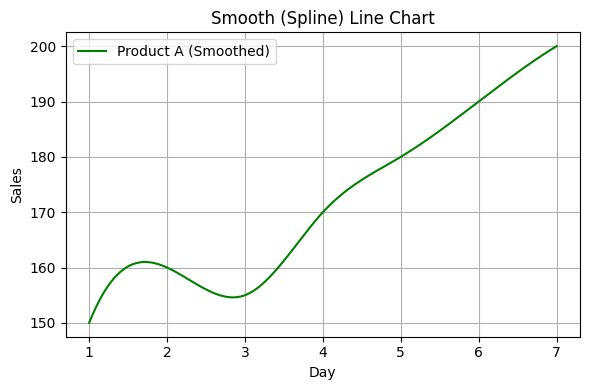

In [23]:
x_smooth = np.linspace(days.min(), days.max(), 300)  # more points for smooth curve
y_smooth = make_interp_spline(days, sales_A)(x_smooth)  # spline interpolation

plt.figure(figsize=(6, 4))
plt.plot(x_smooth, y_smooth, label='Product A (Smoothed)', color='green')
plt.title("Smooth (Spline) Line Chart")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

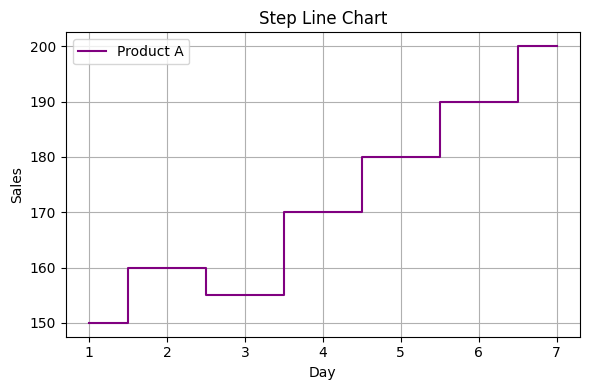

In [24]:
plt.figure(figsize=(6, 4))
plt.step(days, sales_A, where='mid', label='Product A', color='purple')
plt.title("Step Line Chart")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

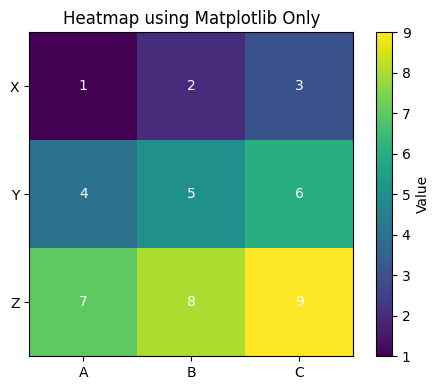

In [26]:
# Sample 2D data (e.g., correlation matrix or confusion matrix)
data = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])



plt.figure(figsize=(5, 4))
plt.imshow(data, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Value')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i, j]}", ha='center', va='center', color='white')

plt.title("Heatmap using Matplotlib Only")
plt.xticks(ticks=[0, 1, 2], labels=['A', 'B', 'C'])
plt.yticks(ticks=[0, 1, 2], labels=['X', 'Y', 'Z'])
plt.tight_layout()
plt.show()

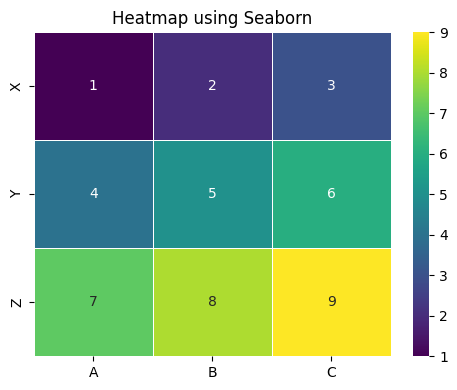

In [27]:
# Sample data
data = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Convert to DataFrame for better labeling
df = pd.DataFrame(data, index=['X', 'Y', 'Z'], columns=['A', 'B', 'C'])

# Plot heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(df, annot=True, cmap='viridis', fmt="d", linewidths=0.5, linecolor='white')
plt.title("Heatmap using Seaborn")
plt.tight_layout()
plt.show()

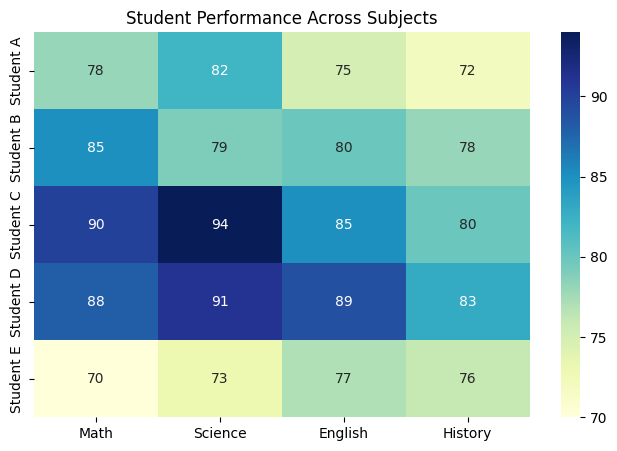

In [28]:
# Sample data: average scores for students across subjects
data = {
    'Math': [78, 85, 90, 88, 70],
    'Science': [82, 79, 94, 91, 73],
    'English': [75, 80, 85, 89, 77],
    'History': [72, 78, 80, 83, 76]
}
students = ['Student A', 'Student B', 'Student C', 'Student D', 'Student E']

df = pd.DataFrame(data, index=students)

plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, cmap='YlGnBu')
plt.title("Student Performance Across Subjects")
plt.show()

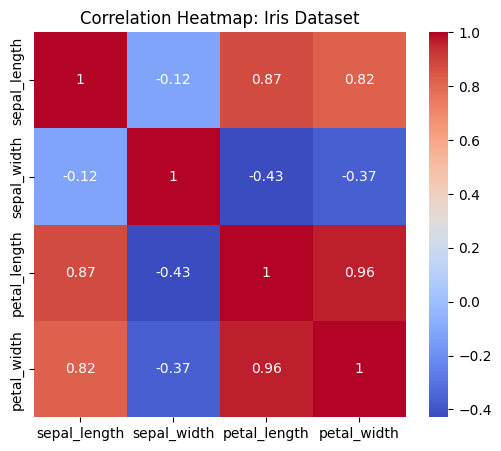

In [29]:
df = sns.load_dataset('iris').drop('species', axis=1)

plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Iris Dataset")
plt.show()

                Hours of Sleep  Stress Level  Screen Time  Mood Score
Hours of Sleep        1.000000     -0.935761    -0.952084    0.767293
Stress Level         -0.935761      1.000000     0.828289   -0.614465
Screen Time          -0.952084      0.828289     1.000000   -0.779990
Mood Score            0.767293     -0.614465    -0.779990    1.000000


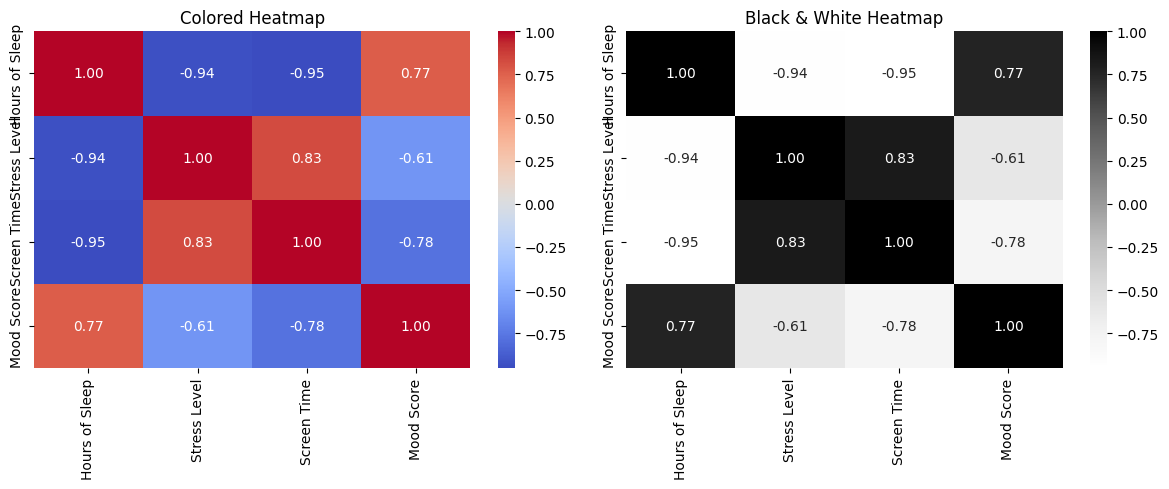

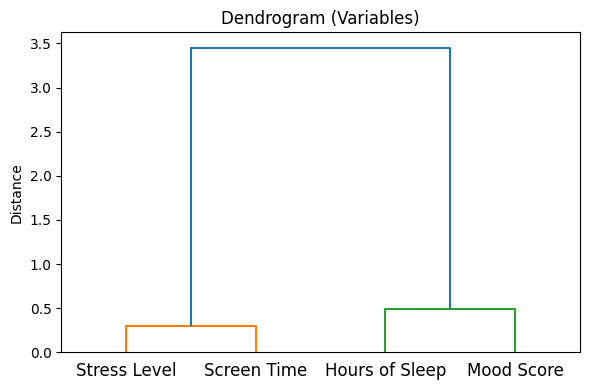

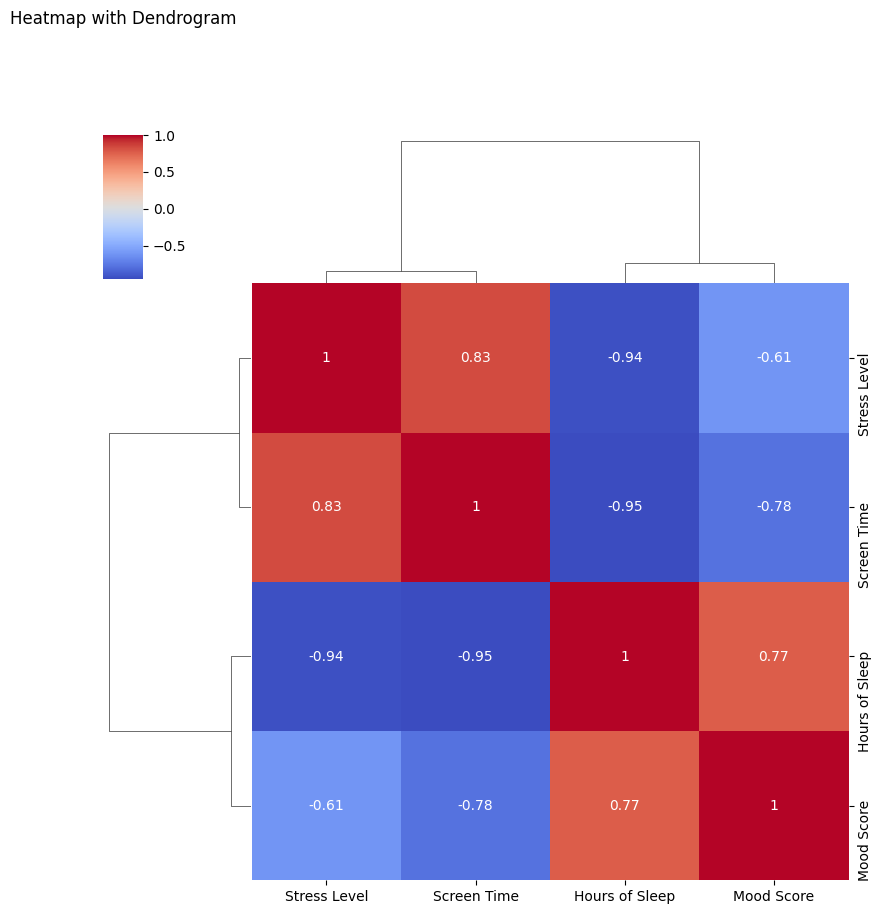

In [30]:
# Step 1: Create the dataset
data = {
    'Hours of Sleep': [7, 6.3, 7.14, 8, 6.2],
    'Stress Level': [2.1, 6.4, 2.8, 0.3, 4.9],
    'Screen Time': [2.4, 3.4, 1.5, 0.5, 4.7],
    'Mood Score': [6.88, 6.68, 6.16, 7.65, 5.37]
}
df = pd.DataFrame(data)

# Step 2: Correlation matrix
corr_matrix = df.corr()

print(corr_matrix)

# Step 3: Plot simple heatmaps (color and B/W)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Colored heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Colored Heatmap")

# Black & White heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Greys', fmt=".2f", ax=axes[1])
axes[1].set_title("Black & White Heatmap")

plt.tight_layout()
plt.show()

# Step 4: Dendrogram (separate from heatmap)
plt.figure(figsize=(6, 4))
linkage = sch.linkage(pdist(corr_matrix), method='average')
sch.dendrogram(linkage, labels=corr_matrix.columns)
plt.title("Dendrogram (Variables)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Step 5: Heatmap with dendrogram (Clustermap)
sns.clustermap(corr_matrix, annot=True, cmap='coolwarm', figsize=(8, 8))
plt.title("Heatmap with Dendrogram", pad=80)
plt.show()

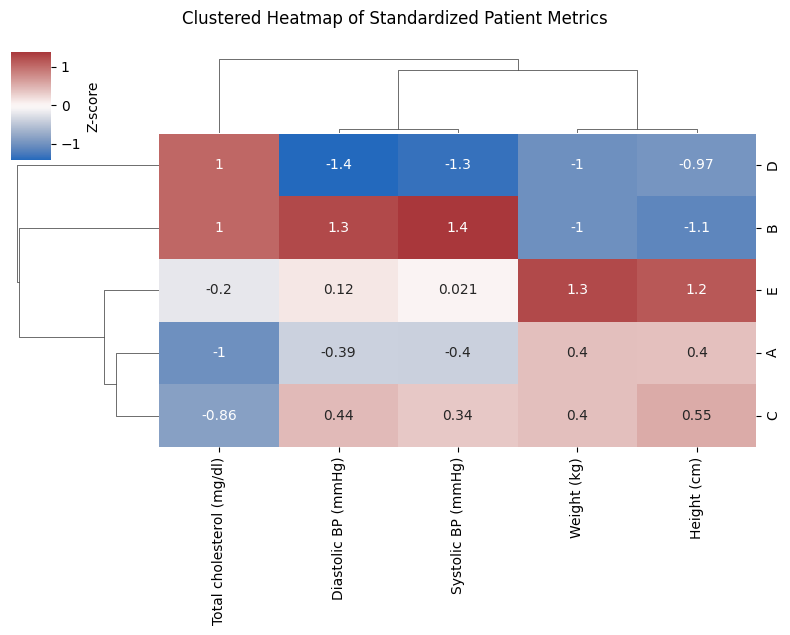

In [31]:
# Step 1: Original patient data
data = {
    'A': [70, 130, 100, 180, 190],
    'B': [86, 147, 90, 170, 215],
    'C': [78, 137, 100, 181, 192],
    'D': [60, 121, 90, 171, 215],
    'E': [75, 134, 106, 185, 200]
}

metrics = [
    'Diastolic BP (mmHg)',
    'Systolic BP (mmHg)',
    'Weight (kg)',
    'Height (cm)',
    'Total cholesterol (mg/dl)'
]


df = pd.DataFrame(data, index=metrics)

# Step 2: Transpose (patients as rows, metrics as columns)
df_t = df.T

# Step 3: Standardize each metric
df_standardized = (df_t - df_t.mean()) / df_t.std()

# Step 4: Plot standardized clustered heatmap
sns.clustermap(df_standardized, cmap='vlag', annot=True, figsize=(8, 6), cbar_kws={'label': 'Z-score'})
plt.suptitle("Clustered Heatmap of Standardized Patient Metrics", y=1.05)
plt.show()

In [32]:
# Sample: Wildfire lat/lon points in Nepal (simulated)
data = [
    [28.3949, 84.1240],  # Near central Nepal
    [27.7172, 85.3240],  # Kathmandu
    [29.2320, 81.8780],  # Far-west
]

# Base map centered on Nepal
m = folium.Map(location=[28.4, 84], zoom_start=7)

# Add heatmap
HeatMap(data).add_to(m)

# Show map
m.save("nepal_wildfires_heatmap.html")